In [ ]:
import marimo as mo

mo.md(r"""

# Neural Posterior Estimation for Lattice Random Walk model

This notebook demonstrates the use of [neural posterior estimation](https://arxiv.org/abs/1912.02762) for paramter estimation of a lattice random walk model. It builds off earlier work by [Simpson & Planck 2025](https://www.biorxiv.org/content/10.1101/2025.05.25.656057v4) (see also https://github.com/ProfMJSimpson/RandomWalkInference).

The notebook is organised as follows:

1. Demonstrate the simulator
2. Demonstrate NPE for Bayesian parameter estimation

---""")

Neural Posterior Estimation for Lattice Random Walk model 
 This notebook demonstrates the use of neural posterior estimation for paramter estimation of a lattice random walk model. It builds off earlier work by Simpson & Planck 2025 (see also https://github.com/ProfMJSimpson/RandomWalkInference ). 
 The notebook is organised as follows: 
 
 Demonstrate the simulator 
 Demonstrate NPE for Bayesian parameter estimation

## 1. Simulator

- **Centered coordinate system**: x ∈ [-Lx/2, Lx/2], y ∈ [0, Ly-1]
- **Initial placement**: Agents placed with probability U in central region around x=0
- **Random sequential updates**: Each time step, Q agents are selected (with replacement) to potentially move
- **Movement probability**: Selected agents move with probability P to a random neighboring site
- **Zero-flux boundaries**: Agents cannot move outside the lattice

---

In [ ]:
"""
Import required modules and set up the simulator
"""
import sys
import os
import time
import psutil
from collections import defaultdict

# Add src directory to path
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

import numpy as np
import matplotlib.pyplot as plt
from simulator import RandomWalkSimulator, plot_simulation_comparison, plot_lattice, plot_column_counts

# Set random seed for reproducibility
np.random.seed(42)

print("✅ Successfully imported simulator modules and timing utilities!")

✅ Successfully imported simulator modules and timing utilities!


In [ ]:
"""
Initialize the simulator with lattice parameters
"""
# Lattice parameters
Lx = 200  # Number of columns
Ly = 50  # Number of rows
initial_region_half_width = 25  # Central region for initial placement

# Create simulator instance
simulator = RandomWalkSimulator(Lx, Ly, initial_region_half_width)

print(f"✅ Created simulator with lattice size {Lx} x {Ly}")
print(f"📍 Coordinate system: x ∈ [{-(Lx//2)}, {Lx//2 if Lx%2==1 else Lx//2-1}], y ∈ [0, {Ly-1}]")
print(f"🎯 Initial region: x ∈ [{-initial_region_half_width}, {initial_region_half_width}]")


✅ Created simulator with lattice size 200 x 50
📍 Coordinate system: x ∈ [-100, 99], y ∈ [0, 49]
🎯 Initial region: x ∈ [-25, 25]


## Simulation Parameters

Now we'll set the key parameters for our random walk simulation:

- **U = 0.3**: Each site in the initial region has a 30% chance of containing an agent at t=0
- **P = 0.7**: When selected, each agent has a 70% chance of moving to a neighboring site
- **T = 100**: We'll run the simulation for 100 time steps

In [ ]:
"""
Set simulation parameters
"""
# Model parameters
U = 0.3  # Initial occupancy probability
P = 0.7  # Movement probability
T = 100  # Number of time steps

print(f"🎲 Simulation parameters:")
print(f"   U (occupancy probability): {U}")
print(f"   P (movement probability): {P}")
print(f"   T (time steps): {T}")


🎲 Simulation parameters:
   U (occupancy probability): 0.3
   P (movement probability): 0.7
   T (time steps): 100


## Running the Simulation

Time to execute the random walk. The simulation will:

1. Initialize agents randomly in the central region based on probability U
2. For each time step, select Q agents (with replacement) to potentially move
3. Each selected agent moves with probability P to a random neighboring site
4. Record the final distribution of agents across columns

In [ ]:
"""
Run the simulation
"""
print("🏃 Running simulation...")

# Run simulation with fixed seed
column_counts, initial_positions, final_positions = simulator.simulate(
    U=U, P=P, T=T, random_seed=123
)

print(f"✅ Simulation completed!")
print(f"🔢 Initial agents: {len(initial_positions)}")
print(f"🔢 Final agents: {len(final_positions)}")
print(f"🔢 Total agents in columns: {np.sum(column_counts)}")
print(f"✅ Agent conservation: {'Yes' if len(initial_positions) == len(final_positions) == np.sum(column_counts) else 'No'}")


🏃 Running simulation...


✅ Simulation completed!
🔢 Initial agents: 793
🔢 Final agents: 793
🔢 Total agents in columns: 793
✅ Agent conservation: Yes


## Visualization: Before and After

Let's visualize the complete simulation results! The plots show:

- **Left**: Initial/Final agent distribution. Initially concentrated in central region, then spread due to random walks
- **Right**: Column counts (the observation vector used for NPE)

The red dashed line marks x=0 (center of the lattice).

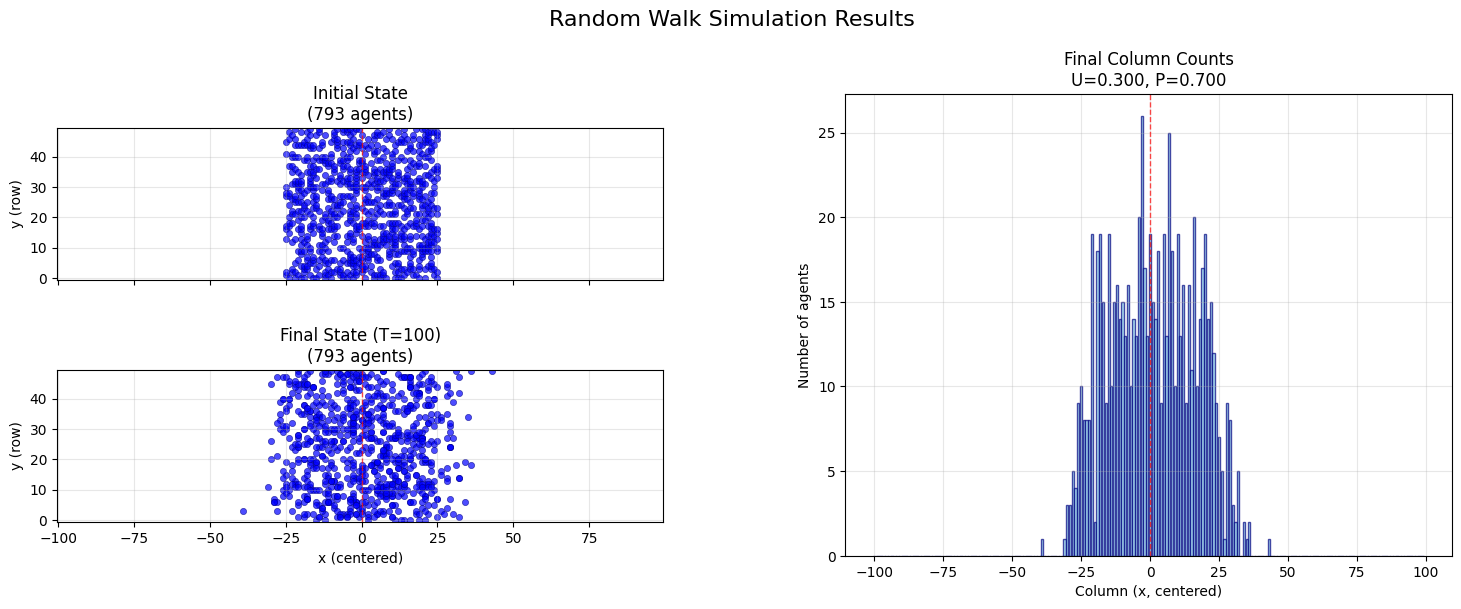

In [ ]:
"""
Create comprehensive visualization
"""
# Create main comparison plot
fig_comparison = plot_simulation_comparison(
    initial_positions=initial_positions,
    final_positions=final_positions,
    column_counts=column_counts,
    Lx=Lx,
    Ly=Ly,
    U=U,
    P=P,
    T=T,
    figsize=(18, 6)
)
fig_comparison.suptitle('Random Walk Simulation Results', fontsize=16, y=1.02)


## Testing & Validation

Let's quickly verify that our simulator properly validates parameters and handles edge cases correctly.

In [ ]:
"""
Test parameter validation and error handling
"""
print("🧪 Testing parameter validation...")

try:
    # Test invalid U
    simulator.simulate(U=1.5, P=0.5, T=10)
    print("❌ ERROR: Should have caught invalid U")
except ValueError as e:
    print(f"✅ Caught invalid U: {e}")

try:
    # Test invalid P
    simulator.simulate(U=0.5, P=1.5, T=10)
    print("❌ ERROR: Should have caught invalid P")
except ValueError as e:
    print(f"✅ Caught invalid P: {e}")

try:
    # Test invalid T
    simulator.simulate(U=0.5, P=0.5, T=-1)
    print("❌ ERROR: Should have caught invalid T")
except ValueError as e:
    print(f"✅ Caught invalid T: {e}")

print("🎉 Parameter validation tests passed!")

🧪 Testing parameter validation...
✅ Caught invalid U: Occupancy probability U must be in (0, 1]
✅ Caught invalid P: Movement probability P must be in [0, 1]
✅ Caught invalid T: Number of time steps T must be non-negative
🎉 Parameter validation tests passed!


In [ ]:
"""
Test reproducibility with random seeds
"""
print("🔄 Testing reproducibility...")

# Run same simulation twice with same seed
result1 = simulator.simulate(U=U, P=P, T=T, random_seed=999)
result2 = simulator.simulate(U=U, P=P, T=T, random_seed=999)

# Check if results are identical
counts_match = np.array_equal(result1[0], result2[0])
initial_match = result1[1] == result2[1]
final_match = result1[2] == result2[2]

print(f"   Column counts match: {'✅' if counts_match else '❌'}")
print(f"   Initial positions match: {'✅' if initial_match else '❌'}")
print(f"   Final positions match: {'✅' if final_match else '❌'}")

if counts_match and initial_match and final_match:
    print("🎉 Reproducibility test passed!")
else:
    print("❌ Reproducibility test failed!")


🔄 Testing reproducibility...


   Column counts match: ✅
   Initial positions match: ✅
   Final positions match: ✅
🎉 Reproducibility test passed!


# 2. Neural Posterior Estimation

## What is NPE?

**Neural Posterior Estimation** is a simulation-based inference method that uses neural networks to learn the posterior distribution p(θ|x) directly from simulated data. Instead of requiring likelihood calculations, NPE:

1. **Generates training data**: Samples parameters θ from priors, simulates corresponding observations x
2. **Trains a neural network**: Learns to map observations x to posterior distributions over parameters θ
3. **Performs inference**: Given real observed data x_obs, the network outputs p(θ|x_obs)

## Sequential NPE (SNPE)

**Sequential NPE** improves upon standard NPE by iteratively refining the posterior estimate:

- **Round 1**: Sample from priors, train initial posterior estimate
- **Round 2+**: Sample from previous posterior estimate, retrain with focused data
- **Convergence**: Stop when posterior estimates stabilize

This focuses computational effort on the most relevant parameter regions, leading to more accurate inference.

## Our Results

We'll examine results from a successful **SNPE run** with:

- **Target parameters**: U=0.3 (occupancy), P=0.7 (movement probability)
- **Sequential rounds**: 10 rounds with convergence monitoring
- **Lattice size**: 100×50 with 100 time steps
- **Training**: 2000 simulations per round

These training hyperparamters were chosen somewhat arbitrarily, just as a proof of concept.

In [ ]:
"""
Import required modules for NPE analysis and visualization
"""

import pickle

import torch

import corner
from pathlib import Path

# Add src directory to path for our modules
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

# Import our NPE and simulator modules
from inference import RandomWalkNPE



✅ Successfully imported NPE analysis modules!
🔧 NumPy version: 2.2.6
🔥 PyTorch version: 2.5.1
📊 Corner version: Available for posterior visualization


## Loading Inference Results

We'll load the results from our successful SNPE workflow run `workflow_20250826_130359`.
This run used Sequential NPE to infer the parameters U and P from simulated random walk data.

In [ ]:
"""
Load the inference results from the workflow run.
We only have the compressed results here. See full .pkl on cluster.
"""
results_path = "/Users/tkimpson/projects/NPE_for_RW_Inference/results/workflow_20250826_130359/inference_results/results_extracted.pkl"

print("📂 Loading inference results...")

with open(results_path, 'rb') as f1:
    results = pickle.load(f1)

# Extract key components
posterior_samples = results['posterior_samples']  # Shape: (5000, 2) for [U, P]
true_parameters = results['true_parameters']      # [0.3, 0.7]


print(f"✅ Successfully loaded results!")
print(f"📊 Posterior samples shape: {posterior_samples.shape}")
print(f"🎯 True parameters: U={true_parameters[0]}, P={true_parameters[1]}")



📂 Loading inference results...
✅ Successfully loaded results!
📊 Posterior samples shape: (5000, 2)
🎯 True parameters: U=0.3, P=0.7


## Corner Plot

Creating corner plot visualization...


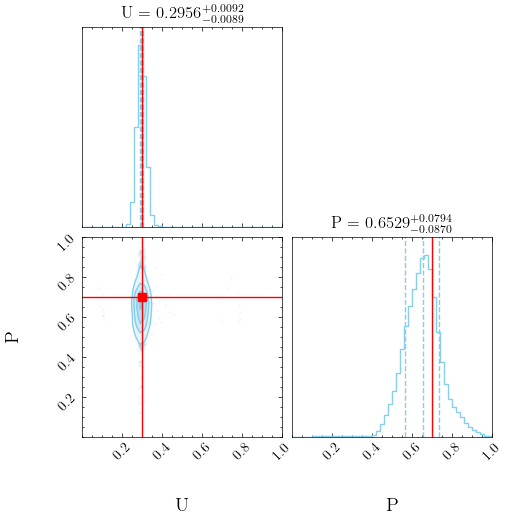

In [ ]:
"""
Create a corner plot of the posterior distribution
"""
import scienceplots
plt.style.use('science')

# Set up the corner plot
print("Creating corner plot visualization...")

# Parameter names and labels
param_names = ['U', 'P']

# Create corner plot
fig = corner.corner(
    posterior_samples,
    labels=param_names,
    truths=true_parameters,
    truth_color='red',
    color='skyblue',
    show_titles=True,
    range=((0,1),(0,1)),
    title_kwargs={'fontsize': 12},
    label_kwargs={'fontsize': 14},
    title_fmt='.4f',
    smooth=1.0,
    smooth1d=1.0,
    bins=50,
    quantiles=[0.16, 0.5, 0.84],  # Show 68% credible intervals
    plot_density=True,
    plot_datapoints=True,
    fill_contours=True,
    max_n_ticks=5
)
plt.xlim(0,1)
plt.show()


## Comparison with Built-in SBI Visualization

Let's also create the standard SBI posterior plots for comparison. The `sbi` library (which powers our NPE implementation)
has built-in visualization functions that provide a different perspective on the same posterior distribution.

🔧 Creating SBI-style posterior plots...


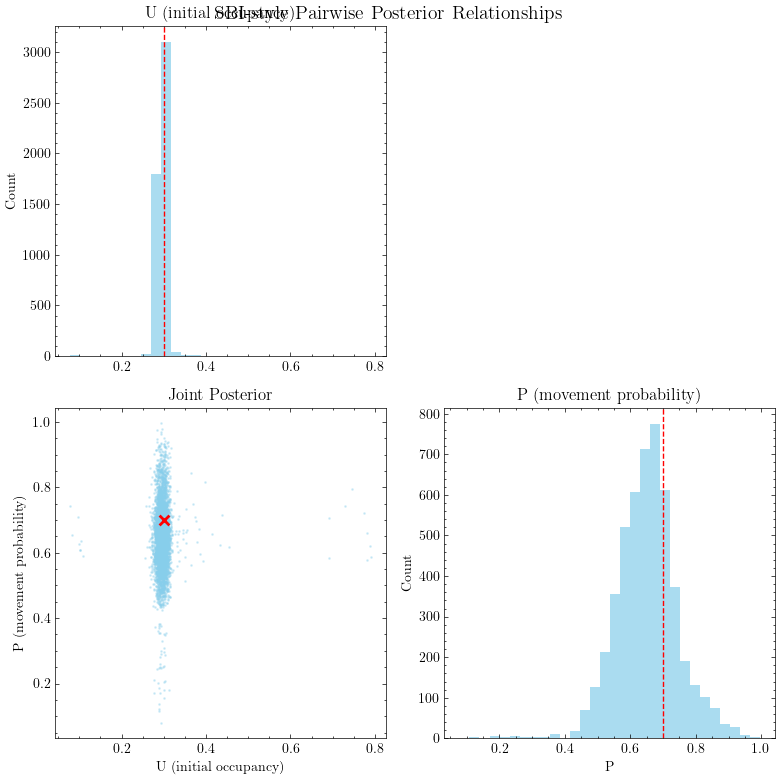

In [ ]:
"""
Create SBI-style posterior visualizations for comparison
"""
print("🔧 Creating SBI-style posterior plots...")

# Convert to torch tensors for SBI plotting functions
posterior_tensor = torch.tensor(posterior_samples, dtype=torch.float32)
true_tensor = torch.tensor(true_parameters, dtype=torch.float32)

# Create a temporary NPE object to access plotting methods
npe_viz = RandomWalkNPE(device='cpu')

# Plot marginal distributions
fig1 = npe_viz.plot_posterior_samples(
    posterior_tensor, 
    true_tensor,
    figsize=(12, 5)
)
fig1.suptitle('SBI-style Marginal Posterior Distributions', fontsize=14, y=1.02)
plt.show()

# Plot pairwise relationships
fig2 = npe_viz.plot_pairwise(
    posterior_tensor,
    true_tensor, 
    figsize=(8, 8)
)
fig2.suptitle('SBI-style Pairwise Posterior Relationships', fontsize=14, y=0.98)
plt.show()
